In [3]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor, ViTConfig
from PIL import Image
import numpy as np


CHECKPOINT_PATH = "Models/vit_crop/checkpoint-32110"
config = ViTConfig.from_pretrained(CHECKPOINT_PATH, output_attentions=True)

inference_model = ViTForImageClassification.from_pretrained(CHECKPOINT_PATH, config=config)
inference_processor = ViTImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}")

Model loaded from Models/vit_crop/checkpoint-32110
Using device: mps


In [4]:
id_to_class = inference_model.config.id2label
class_to_id = inference_model.config.label2id
print(f"Number of classes: {len(id_to_class)}")
print(f"Classes loaded from model configuration")

Number of classes: 60
Classes loaded from model configuration


In [5]:
def predict_fn(images):
    batch_images = []
    for img in images:
        pil_img = Image.fromarray(img.astype('uint8'), 'RGB')
        batch_images.append(pil_img)
        
    inputs = inference_processor(images=batch_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = inference_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    return probs.cpu().numpy()


In [6]:
def generate_grad_rollout(model, processor, pil_image, target_class_id):

    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    model.eval() 
    outputs = model(**inputs)
    logits = outputs.logits
    attentions = outputs.attentions 
    
    target_logit = logits[0, target_class_id]
    
    model.zero_grad()
    grads = torch.autograd.grad(target_logit, attentions, retain_graph=True, allow_unused=True)
    
    with torch.no_grad():
        num_tokens = attentions[0].shape[-1]
        rollout = torch.eye(num_tokens, device=device) 
        
        for i in range(len(attentions)):
            A_l = attentions[i] 
            G_l = grads[i]      
            
            if G_l is None:
                continue
            
            A_l = A_l.squeeze(0) 
            G_l = G_l.squeeze(0) 
            
            alpha = torch.mean(G_l, dim=(-1, -2))    
            alpha = torch.nn.functional.relu(alpha) 
            
            alpha_sum = torch.sum(alpha)
            if alpha_sum > 0:
                alpha = alpha / alpha_sum
            else:
                alpha = torch.ones_like(alpha) / alpha.shape[0]

            A_l_avg = torch.einsum('h,hsd->sd', alpha, A_l) 
            
            I = torch.eye(num_tokens, device=device)
            A_l_avg = A_l_avg + I
            
            A_l_avg = A_l_avg / A_l_avg.sum(dim=-1, keepdim=True)
            
            rollout = torch.matmul(A_l_avg, rollout)
            
    cls_attention_map = rollout[0, 1:] 
    num_patches_side = int(cls_attention_map.shape[0]**0.5)
    heatmap = cls_attention_map.reshape(num_patches_side, num_patches_side).cpu().numpy()
    
    return heatmap

In [7]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.15) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [8]:
graph = Neo4jGraph(url="neo4j://127.0.0.1:7687", username=os.getenv("NEO4J_USER"), password=os.getenv("NEO4J_PASSWORD"), enhanced_schema=True)

In [9]:
from langchain_neo4j.chains.graph_qa.cypher import GraphCypherQAChain

llm = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

In [10]:
ANSWER_GEN_TEMPLATE = """
### Role
You are an expert AI agricultural assistant. Your goal is to provide a clear, actionable, and *relevant* answer to the user's question about their plant.

### Instructions
You will be given three distinct pieces of information:
1.  **`[Original User Question]`**: What the user *actually* asked. This is your primary target.
3.  **`[Retrieved Knowledge]`**: This is a knowledge subgraph providing general context about the diagnosed disease and crop.

### Critical Rules
* Your response MUST directly answer the `[Original User Question]`.
* Be concise and answer only the user query. Do not provide unnecessary elaboration or extra data.
* **DO NOT** try to "confirm" or "validate" the diagnosis using the retrieved knowledge.
* **DO NOT** output phrases like "The provided subgraph does not contain information..." or "I cannot confirm..."
* Use the `[Diagnosis]` to state the "what" and the `[Retrieved Knowledge]` to build the "why" or "how" of your answer.

<context>
{context}
</context>

Question: {question}
Answer:
"""


In [11]:
from langchain_core.prompts import PromptTemplate
ANSWER_GEN_PROMPT = PromptTemplate.from_template(ANSWER_GEN_TEMPLATE)

In [12]:
answer_chain = ANSWER_GEN_PROMPT | llm

In [13]:
CYPHER_SUBGRAPH = """
MATCH (d:Entity {name: $disease})
MATCH (c:Entity {name: $crop})
MATCH (d)-[rA:AFFECTS]->(c)

OPTIONAL MATCH (d)-[rPRESENTS:PRESENTS]->(s:Entity)
OPTIONAL MATCH (d)-[rPATHOGEN:CAUSED_BY]->(p:Entity)
OPTIONAL MATCH (d)-[rTREAT:TREATED_BY]->(t:Entity)

WITH 
     COLLECT(DISTINCT d) +
     COLLECT(DISTINCT c) +
     COLLECT(DISTINCT s) +
     COLLECT(DISTINCT p) +
     COLLECT(DISTINCT t) AS nodes,
     COLLECT(rA) + 
     COLLECT(rPRESENTS) +
     COLLECT(rPATHOGEN) + 
     COLLECT(rTREAT) AS rels

RETURN nodes, rels

"""


Predicted class: 'Tomato,Leaf Mold' (ID: 46)


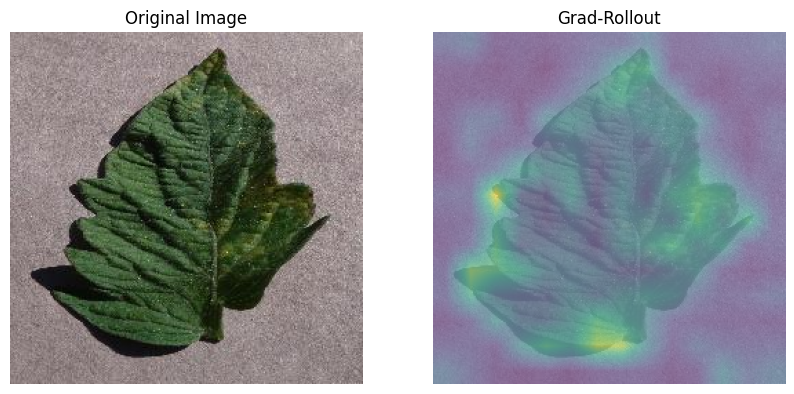

In [26]:
YOUR_IMAGE_PATH_HERE = "dataset/images/Tomato,Leaf Mold/plant_36267.jpg"
YOUR_QUERY_HERE = "What are the effective control measures that can be implemented to manage Tomato Leaf Mold?"

try:
    image_pil = Image.open(YOUR_IMAGE_PATH_HERE).convert("RGB")
    image_np = np.array(image_pil)

    probs = predict_fn([image_np])
    predicted_class_id = np.argmax(probs[0])
    predicted_class_name = id_to_class[predicted_class_id]
    print(f"Predicted class: '{predicted_class_name}' (ID: {predicted_class_id})")

    heatmap = generate_grad_rollout(
        inference_model, 
        inference_processor, 
        image_pil, 
        predicted_class_id
    )
    
    import matplotlib.pyplot as plt
    import cv2
    
    img_size = inference_processor.size['height']
    heatmap_resized = cv2.resize(heatmap, (image_pil.width, image_pil.height))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image_pil)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-Rollout")
    plt.imshow(image_pil, alpha=0.5)
    plt.imshow(heatmap_resized, cmap='viridis', alpha=0.5)
    plt.axis('off')
    plt.show()

    crop, dis = predicted_class_name.split(',')
    subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
    answer = answer_chain.invoke({
        "question": YOUR_QUERY_HERE,
        "context": str(subgraph)
    })
    gen = answer.content
    
except FileNotFoundError:
    print(f"Error: Image file not found at '{YOUR_IMAGE_PATH_HERE}'")
except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure your image file is a valid format (JPG, PNG, etc.)")

In [71]:
def run_pipeline(image, query):

    try:
        image_pil = Image.open(image).convert("RGB")
        image_np = np.array(image_pil)

        probs = predict_fn([image_np])
        predicted_class_id = np.argmax(probs[0])
        predicted_class_name = id_to_class[predicted_class_id]
    
        crop, dis = predicted_class_name.split(',')
        subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
        answer = answer_chain.invoke({
            "question": query,
            "context": str(subgraph)
        })
        # Return both the generated answer content and the retrieved subgraph
        return answer.content, subgraph
        
    except FileNotFoundError:
        print(f"Error: Image file not found at '{image}'")
    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your image file is a valid format (JPG, PNG, etc.)")


In [37]:
from langchain_core.prompts import PromptTemplate

JUDGE_PROMPT = """
You are an evaluation assistant for an agricultural Question-Answering system.

Your task is to evaluate how correct and faithful the system's answer is compared to the ground-truth answer from a Knowledge Graph.

You will receive:
1. The user question.
2. The reference answer (ground truth from KG).
3. The system answer produced by the model.

Evaluate the system answer ONLY based on:
- Semantic correctness: Does it express the same meaning as the reference?
- Factual consistency: Are all facts aligned with the reference answer?
- Completeness: Does it include all essential facts?
- Hallucination detection: Does it add information that is not in the reference answer?

Do NOT judge:
- Grammar
- Style
- Length
- Wording differences (paraphrasing is fine)

Scoring Guidelines:
- Score 1.0 → Completely correct. Same meaning, no missing facts, no hallucinations.
- Score 0.75 → Mostly correct, minor missing details, no major hallucination.
- Score 0.5 → Partially correct; some errors or omissions, or minor hallucination.
- Score 0.25 → Mostly incorrect; several wrong facts or hallucinated details.
- Score 0.0 → Totally incorrect or hallucinated; contradicts the reference answer.

Important:
- The system answer must NOT contain facts absent in the reference.
- If the reference answer is empty but the system answer has facts → score 0 (hallucination).

Your output MUST be a JSON object in this format:

{{
  "score": float (0 to 1),
  "explanation": "Short explanation of correctness and issues"
}}

Now evaluate the answer:

QUESTION: {question}
REFERENCE_ANSWER: {reference}
SYSTEM_ANSWER: {system_answer}

"""

JUDGE_PROMPT_TEMPLATE = PromptTemplate.from_template(JUDGE_PROMPT)

In [42]:
JUDGE_PROMPT_2 = """
You are an evaluation assistant for an agricultural QA system.

You will receive:
1. A user question.
2. The system answer.

Your task is to evaluate general scientific correctness without using a reference answer.

Judge based on:
- Biological/agricultural plausibility
- Scientific correctness
- Absence of hallucinated diseases or treatments
- No contradictions with known plant pathology
- Relevance to the question
- Specificity (not vague)
- Safety (no harmful recommendations)

Scoring:
- 1.0 = fully correct and safe
- 0.75 = mostly correct, minor issues
- 0.5 = partially correct but generally safe
- 0.25 = mostly incorrect or vague
- 0.0 = dangerous, hallucinated, or irrelevant

Output JSON only:
{{
  "score": float,
  "explanation": string
}}

QUESTION: {question}
SYSTEM_ANSWER: {system_answer}

"""

JUDGE_PROMPT_TEMPLATE_2 = PromptTemplate.from_template(JUDGE_PROMPT_2)

In [ ]:
gen

In [43]:
def evaluate_answer(question, generated_answer, subgraph):
    judge_chain = JUDGE_PROMPT_TEMPLATE | llm
    inputs = {
        "question": question,
        "system_answer": generated_answer,
        "reference": subgraph,
    }
    
    evaluation = judge_chain.invoke(inputs)
    return evaluation

def evaluate_answer_2(question, generated_answer):
    judge_chain = JUDGE_PROMPT_TEMPLATE_2 | llm
    inputs = {
        "question": question,
        "system_answer": generated_answer,
    }
    
    evaluation = judge_chain.invoke(inputs)
    return evaluation

In [38]:
evaluate_answer(
    question="What are the effective control measures that can be implemented to manage Tomato Leaf Mold?",
    subgraph=subgraph,
    generated_answer=gen
).content

AIMessage(content='{\n  "score": 1.0,\n  "explanation": "The system answer correctly identifies all the control measures for Tomato Leaf Mold as provided in the reference answer, including Crop Rotation, Cultivation Management, Greenhouse Disinfection, High-Temperature Treatment, Seed Treatment, and Resistant varieties. There are no missing facts or hallucinations."\n}', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'grounding_metadata': {}, 'model_provider': 'google_genai'}, id='lc_run--45879157-36d8-41b7-b1db-49a8e55679ec-0', usage_metadata={'input_tokens': 16766, 'output_tokens': 276, 'total_tokens': 17042, 'input_token_details': {'cache_read': 16363}, 'output_token_details': {'reasoning': 205}})

In [47]:
out2 = evaluate_answer_2(
    question="What are the effective control measures that can be implemented to manage Tomato Leaf Mold?",
    generated_answer=gen
).content

In [48]:
import re

def extract_json(text):
    pattern = r"\{[\s\S]*?\}"
    match = re.search(pattern, text)
    if not match:
        raise ValueError("No JSON object found in the text.")

    json_str = match.group(0)

    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        raise ValueError("Found JSON-like content but failed to parse.")

In [49]:
extract_json(out2)

{'score': 0.75,
 'explanation': "The system provides several generally correct and effective control measures for Tomato Leaf Mold, including cultivation management (e.g., ventilation, spacing), greenhouse disinfection, and the use of resistant varieties, which are all highly relevant and scientifically sound. Crop rotation and seed treatment are also plausible, albeit often less critical for this specific airborne disease compared to other measures. The main point of concern is 'High-Temperature Treatment.' While high temperatures (above 27°C) can inhibit the growth and sporulation of *Cladosporium fulvum* and are part of environmental control strategies in greenhouses (e.g., to reduce humidity), the phrasing 'High-Temperature Treatment' is vague and could be misinterpreted. It's not a standard direct treatment applied to plants for leaf mold, though it can be part of a broader climate management strategy or sanitation process for empty greenhouses. Overall, the answer is mostly corre

In [81]:
import json
import csv
from tqdm import tqdm

def run_full_test(
    test_json_path,
    output_csv_path,
):

    with open(test_json_path, "r") as f:
        dataset = json.load(f)

    rows = []

    for item in tqdm(dataset, desc="Running tests"):
        q_id = item.get("question_id")
        image = item.get("image")
        if image.startswith("/"):
            image = image[1:]
        question = item.get("question")


        try:
            system_answer, subgraph = run_pipeline(image, question)
        except Exception as e:
            system_answer = f"PIPELINE ERROR: {str(e)}"
            subgraph = ""

        try:
            eval1_text = evaluate_answer(question, system_answer, subgraph).content
            eval2_text = evaluate_answer_2(question, system_answer).content
            judge_output_1 = extract_json(eval1_text).get('score')
            judge_output_2 = extract_json(eval2_text).get('score')
            judge_score = judge_output_1 + judge_output_2
            print(f"Evaluated QID {q_id}: New judge_score = {judge_score}")
        except Exception as e:
            print(e)
            break

        rows.append({
            "question_id": q_id,
            "image": image,
            "question": question,
            "system_answer": system_answer,
            "judge_score": judge_score,
        })

    with open(output_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "question_id",
                "image",
                "question",
                "system_answer",
                "judge_score",
            ]
        )
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved results to {output_csv_path}")


In [ ]:
run_full_test(
    test_json_path="dataset/test_dataset/disease_knowledge.json",
    output_csv_path="Results/test_1.csv",
)

In [88]:
import csv

def compute_avg_score(csv_path):
    scores = []

    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                score = float(row["judge_score"])
                scores.append(score)
            except:
                pass  

    if len(scores) == 0:
        raise ValueError("No judge_score values found.")

    avg_score = sum(scores) / len(scores)

    normalized = (avg_score / 2)

    return avg_score, normalized

In [89]:
avg, norm = compute_avg_score("Results/test_1.csv")
print("Average Score (0–2):", avg)
print("Normalized Score (0–10):", norm)

Average Score (0–2): 1.5125
Normalized Score (0–10): 0.75625
